# Methylation Toolkit
Teresa mentioned she wants to see presence/absence for the DNA methylation toolkit in the oyster at my next committee meeting. This is inpsired by a talk she saw about land slugs.

## 0. load libraries

In [2]:
library(tidyverse)
library(rtracklayer)

## 1. read csvs

In [3]:
gtf <- as.data.frame(import('/work/pi_sarah_gignouxwolfsohn_uml_edu/julia_mcdonough_student_uml_edu/ref_files/genome/GCF_053477285.1_ASM5347728v1_genomic.gtf'))
head(gtf)

,seqnames,start,end,width,strand,source,type,score,phase,gene_id,⋯,exon_number,protein_id,anticodon,inference,note,pseudo,exception,transl_except,part,partial
,<fct>,<int>,<int>,<int>,<fct>,<fct>,<fct>,<dbl>,<int>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,NC_136047.1,34876,71533,36658,+,Gnomon,gene,NA,NA,LOC144621260,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,NC_136047.1,34876,71533,36658,+,Gnomon,transcript,NA,NA,LOC144621260,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,NC_136047.1,34876,35035,160,+,Gnomon,exon,NA,NA,LOC144621260,⋯,1,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,NC_136047.1,46195,46780,586,+,Gnomon,exon,NA,NA,LOC144621260,⋯,2,NA,NA,NA,NA,NA,NA,NA,NA,NA
5,NC_136047.1,49378,50230,853,+,Gnomon,exon,NA,NA,LOC144621260,⋯,3,NA,NA,NA,NA,NA,NA,NA,NA,NA
6,NC_136047.1,53798,53912,115,+,Gnomon,exon,NA,NA,LOC144621260,⋯,4,NA,NA,NA,NA,NA,NA,NA,NA,NA


## 2. Find methlyation toolkit genes

want to make a plot with presence/absence of methylation toolkit - starting a df with this info

### writers of DNAme

#### DNMT1
LOC111121210

In [200]:
unique(gtf %>% filter(str_detect(description, "DNA methyltransferase"))%>% select(gene_id, description))

,gene_id,description
,<chr>,<chr>
1,LOC111121210,DNA methyltransferase 1-associated protein 1-like


start data frame

In [201]:
me.tools <- unique(gtf %>% filter(str_detect(description, "DNA methyltransferase"))%>% select(gene_id, description)) 

me.tools <- me.tools %>% 
mutate(gene_common = 'DNMT1') %>%
mutate(present = 'Yes') %>%
# change order of columns
select(gene_common, gene_id, description, present)

head(me.tools)

,gene_common,gene_id,description,present
,<chr>,<chr>,<chr>,<chr>
1,DNMT1,LOC111121210,DNA methyltransferase 1-associated protein 1-like,Yes


#### DNMT2
according to [Gavery and Roberts](https://link.springer.com/content/pdf/10.1186/1471-2164-11-483), a DNMT2 homolog has not been found (at least for *C. gigas*)

In [202]:
me.tools <- me.tools %>% 
add_row(gene_common = "DNMT2", present = 'No')

head(me.tools)

,gene_common,gene_id,description,present
,<chr>,<chr>,<chr>,<chr>
1,DNMT1,LOC111121210,DNA methyltransferase 1-associated protein 1-like,Yes
2,DNMT2,NA,NA,No


#### DNMT3

In [203]:
me.tools <- me.tools %>% 
add_row(gene_common = "DNMT3", present = 'No') %>%
# all of these are writers
mutate(Function = 'Writer')

head(me.tools)

,gene_common,gene_id,description,present,Function
,<chr>,<chr>,<chr>,<chr>,<chr>
1,DNMT1,LOC111121210,DNA methyltransferase 1-associated protein 1-like,Yes,Writer
2,DNMT2,NA,NA,No,Writer
3,DNMT3,NA,NA,No,Writer


### erasers of DNAme

#### TET1
LOC111118472

In [204]:
tet1 <- unique(gtf %>% filter(str_detect(description, "TET1"))%>% select(gene_id, description))
tet1

,gene_id,description
,<chr>,<chr>
1,LOC111118472,methylcytosine dioxygenase TET1-like


In [205]:
me.tools <- me.tools %>% 
add_row(gene_common = "TET1", gene_id = tet1$gene_id, description = tet1$description, present = 'Yes', Function = 'Eraser')

head(me.tools)

,gene_common,gene_id,description,present,Function
,<chr>,<chr>,<chr>,<chr>,<chr>
1,DNMT1,LOC111121210,DNA methyltransferase 1-associated protein 1-like,Yes,Writer
2,DNMT2,NA,NA,No,Writer
3,DNMT3,NA,NA,No,Writer
4,TET1,LOC111118472,methylcytosine dioxygenase TET1-like,Yes,Eraser


#### TET2

In [206]:
unique(gtf %>% filter(str_detect(description, "TET2"))%>% select(gene_id, description))

gene_id,description
<chr>,<chr>


In [207]:
me.tools <- me.tools %>% 
add_row(gene_common = "TET2", present = 'No', Function = 'Eraser')

head(me.tools)

,gene_common,gene_id,description,present,Function
,<chr>,<chr>,<chr>,<chr>,<chr>
1,DNMT1,LOC111121210,DNA methyltransferase 1-associated protein 1-like,Yes,Writer
2,DNMT2,NA,NA,No,Writer
3,DNMT3,NA,NA,No,Writer
4,TET1,LOC111118472,methylcytosine dioxygenase TET1-like,Yes,Eraser
5,TET2,NA,NA,No,Eraser


#### TET3

In [208]:
unique(gtf %>% filter(str_detect(description, "TET"))%>% select(gene_id, description))

,gene_id,description
,<chr>,<chr>
1,LOC111118472,methylcytosine dioxygenase TET1-like


In [209]:
me.tools <- me.tools %>% 
add_row(gene_common = "TET3", present = 'No', Function = 'Eraser')

head(me.tools)

,gene_common,gene_id,description,present,Function
,<chr>,<chr>,<chr>,<chr>,<chr>
1,DNMT1,LOC111121210,DNA methyltransferase 1-associated protein 1-like,Yes,Writer
2,DNMT2,NA,NA,No,Writer
3,DNMT3,NA,NA,No,Writer
4,TET1,LOC111118472,methylcytosine dioxygenase TET1-like,Yes,Eraser
5,TET2,NA,NA,No,Eraser
6,TET3,NA,NA,No,Eraser


### readers

#### MBD1
also absent in land slug

In [210]:
me.tools <- me.tools %>% 
add_row(gene_common = "MBD1", present = 'No', Function = 'Reader')

tail(me.tools)

,gene_common,gene_id,description,present,Function
,<chr>,<chr>,<chr>,<chr>,<chr>
2,DNMT2,NA,NA,No,Writer
3,DNMT3,NA,NA,No,Writer
4,TET1,LOC111118472,methylcytosine dioxygenase TET1-like,Yes,Eraser
5,TET2,NA,NA,No,Eraser
6,TET3,NA,NA,No,Eraser
7,MBD1,NA,NA,No,Reader


#### MBD2
LOC111128560

In [211]:
mbd2 <- unique(gtf %>% filter(str_detect(description, "methyl-CpG"))%>% select(gene_id, description))[2,]
mbd2

,gene_id,description
,<chr>,<chr>
2,LOC111128560,methyl-CpG-binding domain protein 2-like


In [212]:
me.tools <- me.tools %>% 
add_row(gene_common = "MBD2", gene_id = mbd2$gene_id, description = mbd2$description, present = 'Yes', Function = 'Reader')

tail(me.tools)

,gene_common,gene_id,description,present,Function
,<chr>,<chr>,<chr>,<chr>,<chr>
3,DNMT3,NA,NA,No,Writer
4,TET1,LOC111118472,methylcytosine dioxygenase TET1-like,Yes,Eraser
5,TET2,NA,NA,No,Eraser
6,TET3,NA,NA,No,Eraser
7,MBD1,NA,NA,No,Reader
8,MBD2,LOC111128560,methyl-CpG-binding domain protein 2-like,Yes,Reader


#### MBD3
also absent in land slug

In [213]:
me.tools <- me.tools %>% 
add_row(gene_common = "MBD3", present = 'No', Function = 'Reader')

tail(me.tools)

,gene_common,gene_id,description,present,Function
,<chr>,<chr>,<chr>,<chr>,<chr>
4,TET1,LOC111118472,methylcytosine dioxygenase TET1-like,Yes,Eraser
5,TET2,NA,NA,No,Eraser
6,TET3,NA,NA,No,Eraser
7,MBD1,NA,NA,No,Reader
8,MBD2,LOC111128560,methyl-CpG-binding domain protein 2-like,Yes,Reader
9,MBD3,NA,NA,No,Reader


#### MBD4
LOC111107813

In [214]:
mbd4 <- unique(gtf %>% filter(str_detect(description, "methyl-CpG"))%>% select(gene_id, description))[1,]
mbd4

,gene_id,description
,<chr>,<chr>
1,LOC111107813,methyl-CpG-binding domain protein 4-like


In [215]:
me.tools <- me.tools %>% 
add_row(gene_common = "MBD4", gene_id = mbd4$gene_id, description = mbd4$description, present = 'Yes', Function = 'Reader')

tail(me.tools)

,gene_common,gene_id,description,present,Function
,<chr>,<chr>,<chr>,<chr>,<chr>
5,TET2,NA,NA,No,Eraser
6,TET3,NA,NA,No,Eraser
7,MBD1,NA,NA,No,Reader
8,MBD2,LOC111128560,methyl-CpG-binding domain protein 2-like,Yes,Reader
9,MBD3,NA,NA,No,Reader
10,MBD4,LOC111107813,methyl-CpG-binding domain protein 4-like,Yes,Reader


#### MECP2

In [216]:
unique(gtf %>% filter(str_detect(description, "methyl-CpG binding protein 2"))%>% select(gene_id, description))

gene_id,description
<chr>,<chr>


In [217]:
me.tools <- me.tools %>% 
add_row(gene_common = "MECP2", present = 'No', Function = 'Reader')

tail(me.tools)

,gene_common,gene_id,description,present,Function
,<chr>,<chr>,<chr>,<chr>,<chr>
6,TET3,NA,NA,No,Eraser
7,MBD1,NA,NA,No,Reader
8,MBD2,LOC111128560,methyl-CpG-binding domain protein 2-like,Yes,Reader
9,MBD3,NA,NA,No,Reader
10,MBD4,LOC111107813,methyl-CpG-binding domain protein 4-like,Yes,Reader
11,MECP2,NA,NA,No,Reader


### support

#### HELLS
helicase, lymphoid specific

In [218]:
hells <- unique(gtf %>% filter(str_detect(description, "lymphoid-specific"))%>% select(gene_id, description))
hells

,gene_id,description
,<chr>,<chr>
1,LOC111125248,lymphoid-specific helicase-like
2,LOC144622148,lymphoid-specific helicase-like
3,LOC111132030,lymphoid-specific helicase-like


does this mean there are 3 copies of HELLS? (the land slug has 2 copies)

In [219]:
me.tools <- me.tools %>% 
add_row(gene_common = "HELLS", gene_id = hells$gene_id, description = hells$description, present = 'Yes', Function = 'Support')

tail(me.tools)

,gene_common,gene_id,description,present,Function
,<chr>,<chr>,<chr>,<chr>,<chr>
9,MBD3,NA,NA,No,Reader
10,MBD4,LOC111107813,methyl-CpG-binding domain protein 4-like,Yes,Reader
11,MECP2,NA,NA,No,Reader
12,HELLS,LOC111125248,lymphoid-specific helicase-like,Yes,Support
13,HELLS,LOC144622148,lymphoid-specific helicase-like,Yes,Support
14,HELLS,LOC111132030,lymphoid-specific helicase-like,Yes,Support


#### UHRF1
Ubiquitin-like, containing PHD and RING finger domains

In [220]:
uhrf1 <- unique(gtf %>% filter(str_detect(description, "UHRF"))%>% select(gene_id, description))
uhrf1

,gene_id,description
,<chr>,<chr>
1,LOC111122328,E3 ubiquitin-protein ligase UHRF1-like


In [221]:
me.tools <- me.tools %>% 
add_row(gene_common = "UHRF1", gene_id = uhrf1$gene_id, description = uhrf1$description, present = 'Yes', Function = 'Support')

tail(me.tools)

,gene_common,gene_id,description,present,Function
,<chr>,<chr>,<chr>,<chr>,<chr>
10,MBD4,LOC111107813,methyl-CpG-binding domain protein 4-like,Yes,Reader
11,MECP2,NA,NA,No,Reader
12,HELLS,LOC111125248,lymphoid-specific helicase-like,Yes,Support
13,HELLS,LOC144622148,lymphoid-specific helicase-like,Yes,Support
14,HELLS,LOC111132030,lymphoid-specific helicase-like,Yes,Support
15,UHRF1,LOC111122328,E3 ubiquitin-protein ligase UHRF1-like,Yes,Support


#### UHRF2
Ubiquitin-like, containing PHD and RING finger domains

In [222]:
me.tools <- me.tools %>% 
add_row(gene_common = "UHRF2", present = 'No', Function = 'Support')

tail(me.tools)

,gene_common,gene_id,description,present,Function
,<chr>,<chr>,<chr>,<chr>,<chr>
11,MECP2,NA,NA,No,Reader
12,HELLS,LOC111125248,lymphoid-specific helicase-like,Yes,Support
13,HELLS,LOC144622148,lymphoid-specific helicase-like,Yes,Support
14,HELLS,LOC111132030,lymphoid-specific helicase-like,Yes,Support
15,UHRF1,LOC111122328,E3 ubiquitin-protein ligase UHRF1-like,Yes,Support
16,UHRF2,NA,NA,No,Support


### cofactor

#### DMAP 1
DNA methyltransferase 1

In [223]:
dmap1 <- unique(gtf %>% filter(str_detect(description, "DNA methyltransferase"))%>% select(gene_id, description))
dmap1

,gene_id,description
,<chr>,<chr>
1,LOC111121210,DNA methyltransferase 1-associated protein 1-like


In [224]:
me.tools <- me.tools %>% 
add_row(gene_common = "DMAP1", gene_id = dmap1$gene_id, description = dmap1$description, present = 'Yes', Function = 'Cofactor')

tail(me.tools)

,gene_common,gene_id,description,present,Function
,<chr>,<chr>,<chr>,<chr>,<chr>
12,HELLS,LOC111125248,lymphoid-specific helicase-like,Yes,Support
13,HELLS,LOC144622148,lymphoid-specific helicase-like,Yes,Support
14,HELLS,LOC111132030,lymphoid-specific helicase-like,Yes,Support
15,UHRF1,LOC111122328,E3 ubiquitin-protein ligase UHRF1-like,Yes,Support
16,UHRF2,NA,NA,No,Support
17,DMAP1,LOC111121210,DNA methyltransferase 1-associated protein 1-like,Yes,Cofactor


#### EZH2
enhancer of zeste 2 polycomb repressive complex 2 subunit

In [225]:
ezh2 <- unique(gtf %>% filter(str_detect(description, "EZH2"))%>% select(gene_id, description))
ezh2

,gene_id,description
,<chr>,<chr>
1,LOC111123912,histone-lysine N-methyltransferase EZH2-like


In [226]:
me.tools <- me.tools %>% 
add_row(gene_common = "EZH2", gene_id = ezh2$gene_id, description = ezh2$description, present = 'Yes', Function = 'Cofactor')

tail(me.tools)

,gene_common,gene_id,description,present,Function
,<chr>,<chr>,<chr>,<chr>,<chr>
13,HELLS,LOC144622148,lymphoid-specific helicase-like,Yes,Support
14,HELLS,LOC111132030,lymphoid-specific helicase-like,Yes,Support
15,UHRF1,LOC111122328,E3 ubiquitin-protein ligase UHRF1-like,Yes,Support
16,UHRF2,NA,NA,No,Support
17,DMAP1,LOC111121210,DNA methyltransferase 1-associated protein 1-like,Yes,Cofactor
18,EZH2,LOC111123912,histone-lysine N-methyltransferase EZH2-like,Yes,Cofactor


#### G9A

In [227]:
g9a <- unique(gtf %>% filter(str_detect(description, "G9A"))%>% select(gene_id, description))
g9a

gene_id,description
<chr>,<chr>


I also did a blast of the *Drosophila* gene fasta against the eastern oyster and got 0 hits

In [228]:
me.tools <- me.tools %>% 
add_row(gene_common = "G9A", present = 'No', Function = 'Cofactor')

tail(me.tools)

,gene_common,gene_id,description,present,Function
,<chr>,<chr>,<chr>,<chr>,<chr>
14,HELLS,LOC111132030,lymphoid-specific helicase-like,Yes,Support
15,UHRF1,LOC111122328,E3 ubiquitin-protein ligase UHRF1-like,Yes,Support
16,UHRF2,NA,NA,No,Support
17,DMAP1,LOC111121210,DNA methyltransferase 1-associated protein 1-like,Yes,Cofactor
18,EZH2,LOC111123912,histone-lysine N-methyltransferase EZH2-like,Yes,Cofactor
19,G9A,NA,NA,No,Cofactor


#### PCNA
proliferating cell nuclear antigen

In [229]:
pcna <- unique(gtf %>% filter(str_detect(description, "proliferating"))%>% select(gene_id, description))
pcna

,gene_id,description
,<chr>,<chr>
1,LOC111120673,proliferating cell nuclear antigen-like


In [230]:
me.tools <- me.tools %>% 
add_row(gene_common = "PCNA", gene_id = pcna$gene_id, description = pcna$description, present = 'Yes', Function = 'Cofactor')

tail(me.tools)

,gene_common,gene_id,description,present,Function
,<chr>,<chr>,<chr>,<chr>,<chr>
15,UHRF1,LOC111122328,E3 ubiquitin-protein ligase UHRF1-like,Yes,Support
16,UHRF2,NA,NA,No,Support
17,DMAP1,LOC111121210,DNA methyltransferase 1-associated protein 1-like,Yes,Cofactor
18,EZH2,LOC111123912,histone-lysine N-methyltransferase EZH2-like,Yes,Cofactor
19,G9A,NA,NA,No,Cofactor
20,PCNA,LOC111120673,proliferating cell nuclear antigen-like,Yes,Cofactor


#### SETDB1

In [231]:
setdb1 <- unique(gtf %>% filter(str_detect(description, "SETDB1"))%>% select(gene_id, description))
setdb1

,gene_id,description
,<chr>,<chr>
1,LOC144625770,histone-lysine N-methyltransferase SETDB1-like
2,LOC111131506,histone-lysine N-methyltransferase SETDB1-B-like


In [232]:
me.tools <- me.tools %>% 
add_row(gene_common = "SETDB1", gene_id = setdb1$gene_id, description = setdb1$description, present = 'Yes', Function = 'Cofactor')

tail(me.tools)

,gene_common,gene_id,description,present,Function
,<chr>,<chr>,<chr>,<chr>,<chr>
17,DMAP1,LOC111121210,DNA methyltransferase 1-associated protein 1-like,Yes,Cofactor
18,EZH2,LOC111123912,histone-lysine N-methyltransferase EZH2-like,Yes,Cofactor
19,G9A,NA,NA,No,Cofactor
20,PCNA,LOC111120673,proliferating cell nuclear antigen-like,Yes,Cofactor
21,SETDB1,LOC144625770,histone-lysine N-methyltransferase SETDB1-like,Yes,Cofactor
22,SETDB1,LOC111131506,histone-lysine N-methyltransferase SETDB1-B-like,Yes,Cofactor


#### SUV39H1

In [233]:
suv39h1 <- unique(gtf %>% filter(str_detect(description, "SUV"))%>% select(gene_id, description))
suv39h1

,gene_id,description
,<chr>,<chr>
1,LOC111110608,histone-lysine N-methyltransferase SUV39H2-like
2,LOC111133030,"ATP-dependent RNA helicase SUV3 homolog, mitochondrial-like"


In [234]:
me.tools <- me.tools %>% 
add_row(gene_common = "SUV39H1", present = 'No', Function = 'Cofactor')

tail(me.tools)

,gene_common,gene_id,description,present,Function
,<chr>,<chr>,<chr>,<chr>,<chr>
18,EZH2,LOC111123912,histone-lysine N-methyltransferase EZH2-like,Yes,Cofactor
19,G9A,NA,NA,No,Cofactor
20,PCNA,LOC111120673,proliferating cell nuclear antigen-like,Yes,Cofactor
21,SETDB1,LOC144625770,histone-lysine N-methyltransferase SETDB1-like,Yes,Cofactor
22,SETDB1,LOC111131506,histone-lysine N-methyltransferase SETDB1-B-like,Yes,Cofactor
23,SUV39H1,NA,NA,No,Cofactor


### Demethylation pathway

#### AICDA
activation induced cytidine deaminase

In [235]:
aicda <- unique(gtf %>% filter(str_detect(description, "cytidine deaminase"))%>% select(gene_id, description))
aicda

,gene_id,description
,<chr>,<chr>
1,LOC111136709,cytidine deaminase-like
2,LOC111138297,cytidine deaminase-like
3,LOC111138152,cytidine deaminase-like


but when I download the human AICDA gene fasta and blast it against the oyster genome, i get a hit on an uncharacterized gene (LOC111116074) with 86% identity

so this is a tentative match? maybe it's only characterized as a homolog if it's above 90% or something

In [236]:
me.tools <- me.tools %>% 
add_row(gene_common = "AICDA", gene_id = 'LOC111116074', description = 'activation induced cytidine deaminase', present = 'Yes', Function = 'Demethylation Pathway')

tail(me.tools)

,gene_common,gene_id,description,present,Function
,<chr>,<chr>,<chr>,<chr>,<chr>
19,G9A,NA,NA,No,Cofactor
20,PCNA,LOC111120673,proliferating cell nuclear antigen-like,Yes,Cofactor
21,SETDB1,LOC144625770,histone-lysine N-methyltransferase SETDB1-like,Yes,Cofactor
22,SETDB1,LOC111131506,histone-lysine N-methyltransferase SETDB1-B-like,Yes,Cofactor
23,SUV39H1,NA,NA,No,Cofactor
24,AICDA,LOC111116074,activation induced cytidine deaminase,Yes,Demethylation Pathway


#### GADD45A
Growth Arrest and DNA Damage-Inducible Alpha

In [237]:
gadd <- unique(gtf %>% filter(str_detect(description, "GADD45 al"))%>% select(gene_id, description))
gadd

,gene_id,description
,<chr>,<chr>
1,LOC111118479,growth arrest and DNA damage-inducible protein GADD45 alpha-like
2,LOC111118431,growth arrest and DNA damage-inducible protein GADD45 alpha-like


In [238]:
me.tools <- me.tools %>% 
add_row(gene_common = "GADD45A", gene_id = gadd$gene_id, description = gadd$description, present = 'Yes', Function = 'Demethylation Pathway')

tail(me.tools)

,gene_common,gene_id,description,present,Function
,<chr>,<chr>,<chr>,<chr>,<chr>
21,SETDB1,LOC144625770,histone-lysine N-methyltransferase SETDB1-like,Yes,Cofactor
22,SETDB1,LOC111131506,histone-lysine N-methyltransferase SETDB1-B-like,Yes,Cofactor
23,SUV39H1,NA,NA,No,Cofactor
24,AICDA,LOC111116074,activation induced cytidine deaminase,Yes,Demethylation Pathway
25,GADD45A,LOC111118479,growth arrest and DNA damage-inducible protein GADD45 alpha-like,Yes,Demethylation Pathway
26,GADD45A,LOC111118431,growth arrest and DNA damage-inducible protein GADD45 alpha-like,Yes,Demethylation Pathway


#### SMUG1
single-strand-selective monofunctional uracil-DNA glycosylase 1

In [239]:
smug <- unique(gtf %>% filter(str_detect(description, "uracil-DNA glycosylase"))%>% select(gene_id, description))
smug

,gene_id,description
,<chr>,<chr>
1,LOC111133661,uracil-DNA glycosylase-like
2,LOC111114668,uracil-DNA glycosylase-like


a blast with the human SMUG1 gene resulted in 0 hits against the eastern oyster genome - but we do have two uracil-DNA glycolase genes so that has to be similar to SMUG 1? (and the land slug has 2 of these as well)

In [240]:
me.tools <- me.tools %>% 
add_row(gene_common = "SMUG1", gene_id = smug$gene_id, description = smug$description, present = 'Yes', Function = 'Demethylation Pathway')

tail(me.tools)

,gene_common,gene_id,description,present,Function
,<chr>,<chr>,<chr>,<chr>,<chr>
23,SUV39H1,NA,NA,No,Cofactor
24,AICDA,LOC111116074,activation induced cytidine deaminase,Yes,Demethylation Pathway
25,GADD45A,LOC111118479,growth arrest and DNA damage-inducible protein GADD45 alpha-like,Yes,Demethylation Pathway
26,GADD45A,LOC111118431,growth arrest and DNA damage-inducible protein GADD45 alpha-like,Yes,Demethylation Pathway
27,SMUG1,LOC111133661,uracil-DNA glycosylase-like,Yes,Demethylation Pathway
28,SMUG1,LOC111114668,uracil-DNA glycosylase-like,Yes,Demethylation Pathway


#### TDG
thymine DNA glycolase

In [241]:
tdg <- unique(gtf %>% filter(str_detect(description, "thymine DNA glycosylase"))%>% select(gene_id, description))
tdg

gene_id,description
<chr>,<chr>


but when I do a blast search, I get a 76% hit on an uncharacterized gene LOC111109690 with 2 transcript variants

In [242]:
me.tools <- me.tools %>% 
add_row(gene_common = "TDG", gene_id = 'LOC111109690', description = 'thymine DNA glycolase', present = 'Yes', Function = 'Demethylation Pathway')

tail(me.tools)

,gene_common,gene_id,description,present,Function
,<chr>,<chr>,<chr>,<chr>,<chr>
24,AICDA,LOC111116074,activation induced cytidine deaminase,Yes,Demethylation Pathway
25,GADD45A,LOC111118479,growth arrest and DNA damage-inducible protein GADD45 alpha-like,Yes,Demethylation Pathway
26,GADD45A,LOC111118431,growth arrest and DNA damage-inducible protein GADD45 alpha-like,Yes,Demethylation Pathway
27,SMUG1,LOC111133661,uracil-DNA glycosylase-like,Yes,Demethylation Pathway
28,SMUG1,LOC111114668,uracil-DNA glycosylase-like,Yes,Demethylation Pathway
29,TDG,LOC111109690,thymine DNA glycolase,Yes,Demethylation Pathway


## Plot

In [169]:
head(me.tools)

,gene_common,gene_id,description,present,Function
,<chr>,<chr>,<chr>,<chr>,<chr>
1,DNMT1,LOC111121210,DNA methyltransferase 1-associated protein 1-like,Yes,writer
2,DNMT2,NA,NA,No,writer
3,DNMT3,NA,NA,No,writer
4,TET1,LOC111118472,methylcytosine dioxygenase TET1-like,Yes,Eraser
5,TET2,NA,NA,No,Eraser
6,TET3,NA,NA,No,Eraser


In [192]:
me.df <- me.tools %>%
  distinct(gene_common, present, Function)

head(me.df)

,gene_common,present,Function
,<chr>,<chr>,<chr>
1,DNMT1,Yes,writer
2,DNMT2,No,writer
3,DNMT3,No,writer
4,TET1,Yes,Eraser
5,TET2,No,Eraser
6,TET3,No,Eraser


In [193]:
me.df$Function <- str_to_title(me.df$Function) 
head(me.df)

,gene_common,present,Function
,<chr>,<chr>,<chr>
1,DNMT1,Yes,Writer
2,DNMT2,No,Writer
3,DNMT3,No,Writer
4,TET1,Yes,Eraser
5,TET2,No,Eraser
6,TET3,No,Eraser


In [252]:
# keep plot in order as seen in df
me.df <- me.df %>%
  mutate(
    Function = factor(Function, levels = unique(Function)),
    gene_common = factor(gene_common, levels = rev(unique(gene_common)))
  )

# change y/n to absent/present
me.df <- me.df %>%
  mutate(present = recode(present,
                          "Yes" = "Present",
                          "No" = "Absent"))

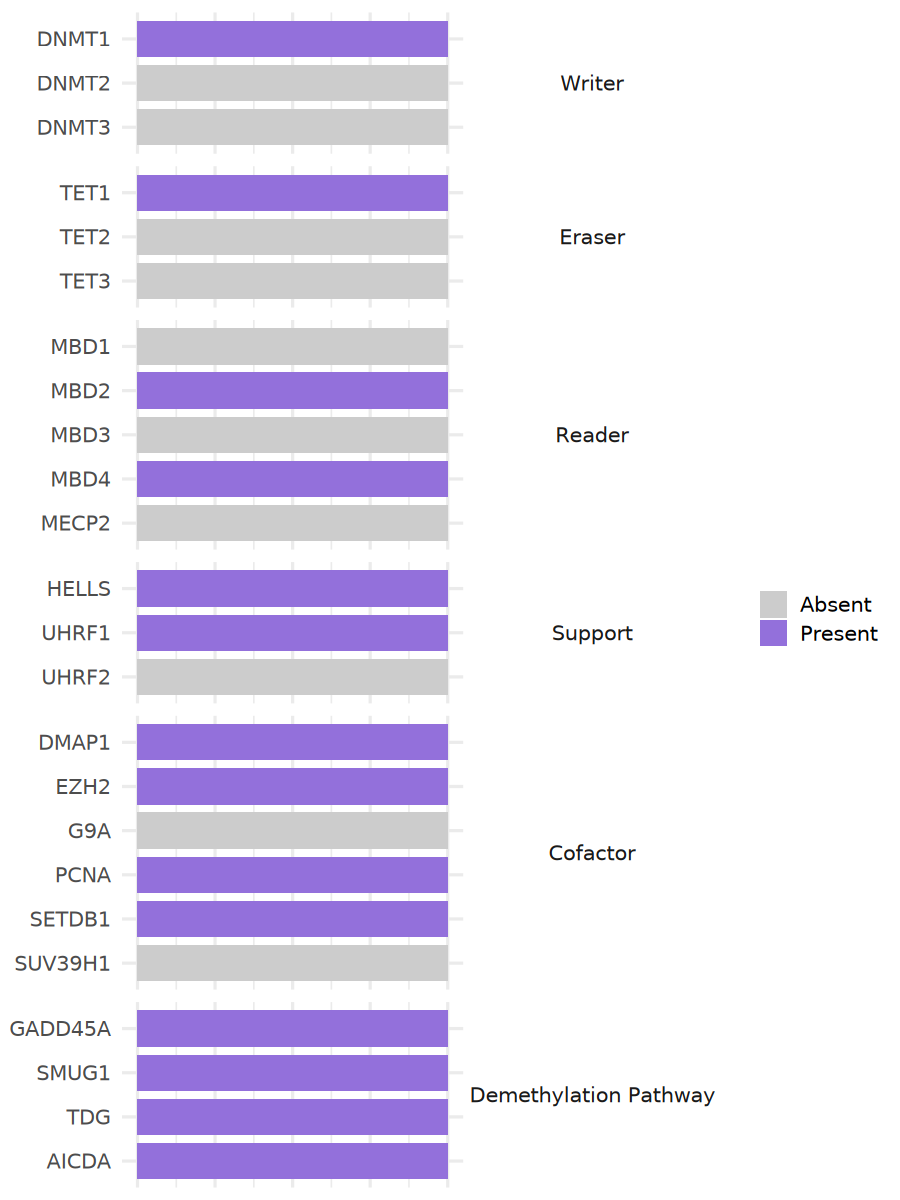

In [256]:
options(repr.plot.height = 10, repr.plot.width = 7.5)

ggplot(me.df, aes(y = gene_common, x = 1, fill = present)) +
  geom_col(width = 0.8) +
  facet_grid(Function ~ ., scales = "free_y", space = "free_y") +
  scale_fill_manual(
    values = c("Present" = "mediumpurple", "Absent" = "grey80")
  ) +
  labs(x = NULL, y = NULL) +
  theme_minimal(base_size = 15) +
  theme(
    strip.placement = "outside",
    strip.background = element_blank(),
    strip.text.y = element_text(angle = 0),
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank()
  ) +
labs(fill = '')
